<a href="https://colab.research.google.com/github/romarud082/aspire-gpa-predictor/blob/main/ASPIRE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1: Import the tools we need

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import os

print(os.listdir())

['.config', 'Student_performance_data _.csv', 'sample_data']


In [ ]:
import pandas as pd

df = pd.read_csv("/content/Student_performance_data _.csv")

df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
print(df.shape)
print(df.columns)

df.info()

(2392, 15)
Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  M

In [ ]:
print(df.isnull().sum())

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [ ]:
target = "GPA"

y = df["GPA"]

X = df.drop(columns=["GPA", "GradeClass", "StudentID"])

print(X.columns.tolist())

print("Inputs:")
print(X.columns)

print("\nTarget:")
print(target)

['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']
Inputs:
Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering'],
      dtype='object')

Target:
GPA


In [ ]:
numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

print("Numerical columns:")
print(list(numeric_columns))

print("\nCategorical columns:")
print(list(categorical_columns))

Numerical columns:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

Categorical columns:
[]


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_columns)
    ],
    remainder="passthrough"
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training students:", len(X_train))
print("Testing students:", len(X_test))

Training students: 1913
Testing students: 479


In [ ]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [ ]:
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 0.15529483485748086
RMSE: 0.196625129356709
R²: 0.9532471681022928


In [ ]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=5,
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))
tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)
print("R²:", tree_r2)

Decision Tree
MAE: 0.26414042466566073
RMSE: 0.3300683769647981
R²: 0.8682539161914872


In [ ]:
forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_rmse = np.sqrt(mean_squared_error(y_test, forest_predictions))
forest_r2 = r2_score(y_test, forest_predictions)

print("Random Forest")
print("MAE:", forest_mae)
print("RMSE:", forest_rmse)
print("R²:", forest_r2)

Random Forest
MAE: 0.1908241706555277
RMSE: 0.24595763044758712
R²: 0.9268439109198162


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        tree_mae,
        forest_mae
    ],
    "RMSE": [
        linear_rmse,
        tree_rmse,
        forest_rmse
    ],
    "R2": [
        linear_r2,
        tree_r2,
        forest_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,0.155295,0.196625,0.953247
1,Decision Tree,0.264140,0.330068,0.868254
2,Random Forest,0.190824,0.245958,0.926844


In [ ]:
print(X.columns.tolist())

['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']


In [ ]:
my_data = pd.DataFrame({
    "Age": [16],
    "Gender": [1],
    "Ethnicity": [0],
    "ParentalEducation": [3],
    "StudyTimeWeekly": [10],
    "Absences": [3],
    "Tutoring": [0],
    "ParentalSupport": [4],
    "Extracurricular": [1],
    "Sports": [0],
    "Music": [1],
    "Volunteering": [1]
})

my_data

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering
0,16,1,0,3,10,3,0,4,1,0,1,1


In [ ]:
my_predicted_gpa = linear_model.predict(my_data)[0]

print("My predicted GPA:", round(my_predicted_gpa, 2))

My predicted GPA: 3.44


In [ ]:
print("My Predicted GPA:", round(my_predicted_gpa, 2))
print("Kaggle Average GPA:", round(df["GPA"].mean(), 2))
print("Kaggle Median GPA:", round(df["GPA"].median(), 2))
print("Highest GPA in Dataset:", round(df["GPA"].max(), 2))
print("Lowest GPA in Dataset:", round(df["GPA"].min(), 2))

My Predicted GPA: 3.44
Kaggle Average GPA: 1.91
Kaggle Median GPA: 1.89
Highest GPA in Dataset: 4.0
Lowest GPA in Dataset: 0.0


In [ ]:
percentile = (df["GPA"] < my_predicted_gpa).mean() * 100

print("My Predicted GPA:", round(my_predicted_gpa, 2))
print("GPA Percentile:", round(percentile, 1), "%")

My Predicted GPA: 3.44
GPA Percentile: 95.9 %


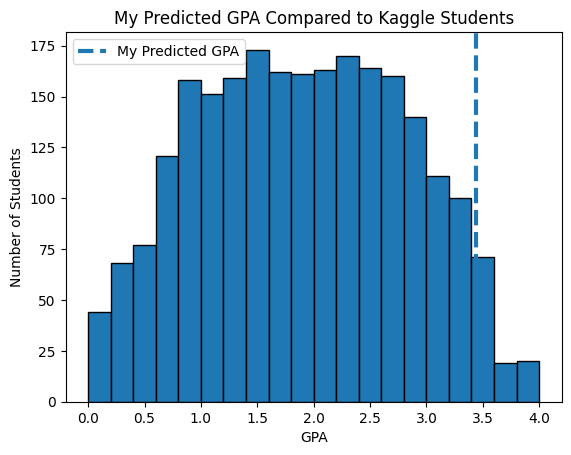

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["GPA"], bins=20, edgecolor="black")

plt.axvline(
    my_predicted_gpa,
    linestyle="--",
    linewidth=3,
    label="My Predicted GPA"
)

plt.xlabel("GPA")
plt.ylabel("Number of Students")
plt.title("My Predicted GPA Compared to Kaggle Students")

plt.legend()

plt.show()

In [ ]:
similar_students = df[
    (df["Age"] == my_data["Age"][0]) &
    (abs(df["StudyTimeWeekly"] - my_data["StudyTimeWeekly"][0]) <= 3) &
    (abs(df["Absences"] - my_data["Absences"][0]) <= 3) &
    (df["Tutoring"] == my_data["Tutoring"][0]) &
    (df["ParentalSupport"] == my_data["ParentalSupport"][0])
]

print("Number of similar students:", len(similar_students))

similar_students[
    [
        "Age",
        "StudyTimeWeekly",
        "Absences",
        "Tutoring",
        "ParentalSupport",
        "GPA"
    ]
]

Number of similar students: 5


,Age,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,GPA
307,16,9.926455,4,0,4,3.645738
1280,16,12.856668,5,0,4,3.432685
2046,16,10.642359,6,0,4,3.125270
2326,16,11.136888,4,0,4,3.546433
2358,16,8.367667,2,0,4,3.286585


In [ ]:
actual_average = similar_students["GPA"].mean()

print("My Model's Predicted GPA:", round(my_predicted_gpa, 2))
print("Similar Students' Average Actual GPA:", round(actual_average, 2))
print("Difference:", round(abs(my_predicted_gpa - actual_average), 2))

My Model's Predicted GPA: 3.44
Similar Students' Average Actual GPA: 3.41
Difference: 0.04
